## Section 1: Introduction

### CRISP-DM : Business Understanding

This dataset contains German doctor reviews.  
The goal is to build machine learning models that predict a doctor's rating (1–6) based on the textual review.

We follow CRISP-DM:
1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling  
5. Evaluation  
6. Deployment / Interpretability (Permutation Importance + TF-IDF weights)

We use two models:
- Logistic Regression (baseline)
- Linear Support Vector Machine (LinearSVC)

## Section 2: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string

# Train-test split
from sklearn.model_selection import train_test_split

# Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, cohen_kappa_score,
    roc_curve, auc
)

# Interpretability
from sklearn.inspection import permutation_importance

pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid")

In [3]:
import os
import matplotlib as mpl

FIG_DIR = "figures_text"
os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300

DEFAULT_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
sns.set_palette(DEFAULT_PALETTE)

## SECTION 3 — Load Dataset

We load the German doctor reviews CSV and inspect columns.


In [4]:
df = pd.read_csv("2021_german_doctor_reviews.csv")
df.head()

,index,rating,comment
0,0,2.0,"Ich bin franzose und bin seit ein paar Wochen in muenchen. Ich hatte Zahn Schmerzen und mein Kollegue hat mir Dr mainka empfohlen. Ich habe schnell ein Termin bekommen, das Team war nett und meine schmerzen sind weg!! Ich bin als Angst Patient sehr zurieden!!"
1,1,6.0,"Dieser Arzt ist das unmöglichste was mir in meinem Leben je begegnet ist,er ist unfreundlich ,sehr herablassend und medizinisch unkompetent.Nach seiner Diagnose bin ich zu einem anderen Hautarzt gegangen der mich ordentlich behandelt hat und mir auch half.Meine Beschweerden hatten einen völlig anderen Grund.<br />\nNach seiner "" Behandlung "" und Diagnose ,waren seine letzten Worte .....und tschüss.Alles inerhalb von ca 5 Minuten."
2,2,1.0,Hatte akute Beschwerden am Rücken. Herr Magura war der erste Arzt der sich wirklich Zeit für einen Therapieplan genommen hat um nachhaltig meine Schmerzen zu beseitigen
3,3,1.0,"Nachdem ich in der Klinik nur ungenaue Angaben erhalten habe, welche Sportarten mein herzkranker Sohn machen darf, wandte ich mich an Dr. Roithmaier, den ich bereits bei einer Veranstaltung der Selbsthilfegruppe ""Junge Herzen Bayern"" kennengelernt hatte. Dr. Roithmaier nahm sich sehr viel Zeit, erläuterte die Untersuchung ausführlich und erklärte genau, welche Sportarten infrage kommen und warum andere nicht. Wir sind wirklich sehr gut beraten worden."
4,4,1.0,"Frau Dr. Vetter kenne ich seit vielen Jahren, sie hat mir bei vielen Problemen sehr kompetent und sehr <br />\numsichtig geholfen. Sie hat mich immer aufgerichtet, wenn es mir schlecht ging.Und sie hat auch viel Ahnung von anderen Fachgebieten. Ich bin sehr zufrieden und kann sie nur wärmstens empfehlen.<br />\nGestern war ich mit meiner Tochter bei ihr . Auch sie war total begeistert."


## SECTION 4 — Data Understanding

Check shape, missing values, sample text, and class distribution.


In [5]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

df['rating'].value_counts()

Shape: (439280, 3)

Missing values:
 index         0
rating     9544
comment       0
dtype: int64


rating
1.0    349813
2.0     22151
5.0     19547
6.0     17296
4.0     12269
3.0      8660
Name: count, dtype: int64

## SECTION 5 — Text Cleaning

We normalize the reviews:
- Lowercase
- Remove punctuation
- Remove numbers
- Remove extra spaces
- Remove non-German characters (optional)


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\säöüß]", " ", text)  # keep German chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_comment"] = df["comment"].apply(clean_text)
df.head()

,index,rating,comment,clean_comment
0,0,2.0,"Ich bin franzose und bin seit ein paar Wochen in muenchen. Ich hatte Zahn Schmerzen und mein Kollegue hat mir Dr mainka empfohlen. Ich habe schnell ein Termin bekommen, das Team war nett und meine schmerzen sind weg!! Ich bin als Angst Patient sehr zurieden!!",ich bin franzose und bin seit ein paar wochen in muenchen ich hatte zahn schmerzen und mein kollegue hat mir dr mainka empfohlen ich habe schnell ein termin bekommen das team war nett und meine schmerzen sind weg ich bin als angst patient sehr zurieden
1,1,6.0,"Dieser Arzt ist das unmöglichste was mir in meinem Leben je begegnet ist,er ist unfreundlich ,sehr herablassend und medizinisch unkompetent.Nach seiner Diagnose bin ich zu einem anderen Hautarzt gegangen der mich ordentlich behandelt hat und mir auch half.Meine Beschweerden hatten einen völlig anderen Grund.<br />\nNach seiner "" Behandlung "" und Diagnose ,waren seine letzten Worte .....und tschüss.Alles inerhalb von ca 5 Minuten.",dieser arzt ist das unmöglichste was mir in meinem leben je begegnet ist er ist unfreundlich sehr herablassend und medizinisch unkompetent nach seiner diagnose bin ich zu einem anderen hautarzt gegangen der mich ordentlich behandelt hat und mir auch half meine beschweerden hatten einen völlig anderen grund br nach seiner behandlung und diagnose waren seine letzten worte und tschüss alles inerhalb von ca minuten
2,2,1.0,Hatte akute Beschwerden am Rücken. Herr Magura war der erste Arzt der sich wirklich Zeit für einen Therapieplan genommen hat um nachhaltig meine Schmerzen zu beseitigen,hatte akute beschwerden am rücken herr magura war der erste arzt der sich wirklich zeit für einen therapieplan genommen hat um nachhaltig meine schmerzen zu beseitigen
3,3,1.0,"Nachdem ich in der Klinik nur ungenaue Angaben erhalten habe, welche Sportarten mein herzkranker Sohn machen darf, wandte ich mich an Dr. Roithmaier, den ich bereits bei einer Veranstaltung der Selbsthilfegruppe ""Junge Herzen Bayern"" kennengelernt hatte. Dr. Roithmaier nahm sich sehr viel Zeit, erläuterte die Untersuchung ausführlich und erklärte genau, welche Sportarten infrage kommen und warum andere nicht. Wir sind wirklich sehr gut beraten worden.",nachdem ich in der klinik nur ungenaue angaben erhalten habe welche sportarten mein herzkranker sohn machen darf wandte ich mich an dr roithmaier den ich bereits bei einer veranstaltung der selbsthilfegruppe junge herzen bayern kennengelernt hatte dr roithmaier nahm sich sehr viel zeit erläuterte die untersuchung ausführlich und erklärte genau welche sportarten infrage kommen und warum andere nicht wir sind wirklich sehr gut beraten worden
4,4,1.0,"Frau Dr. Vetter kenne ich seit vielen Jahren, sie hat mir bei vielen Problemen sehr kompetent und sehr <br />\numsichtig geholfen. Sie hat mich immer aufgerichtet, wenn es mir schlecht ging.Und sie hat auch viel Ahnung von anderen Fachgebieten. Ich bin sehr zufrieden und kann sie nur wärmstens empfehlen.<br />\nGestern war ich mit meiner Tochter bei ihr . Auch sie war total begeistert.",frau dr vetter kenne ich seit vielen jahren sie hat mir bei vielen problemen sehr kompetent und sehr br umsichtig geholfen sie hat mich immer aufgerichtet wenn es mir schlecht ging und sie hat auch viel ahnung von anderen fachgebieten ich bin sehr zufrieden und kann sie nur wärmstens empfehlen br gestern war ich mit meiner tochter bei ihr auch sie war total begeistert


In [9]:
# Count missing ratings before cleaning
print("Missing ratings before cleaning:", df['rating'].isnull().sum())

# Drop rows where the target (rating) is NaN
df = df.dropna(subset=['rating'])

# Reset index after dropping rows
df = df.reset_index(drop=True)

print("Missing ratings after cleaning:", df['rating'].isnull().sum())
print("New dataset shape:", df.shape)

Missing ratings before cleaning: 9544
Missing ratings after cleaning: 0
New dataset shape: (429736, 4)


## SECTION 6 — Train-Test Split


In [10]:
X = df["clean_comment"]
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((322302,), (107434,))

## SECTION 7 — TF-IDF Vectorization

We limit vocabulary to improve performance and avoid overfitting.


In [11]:
tfidf = TfidfVectorizer(
    max_features=30000,   # adjust as needed
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape, X_test_tfidf.shape

((322302, 30000), (107434, 30000))

## SECTION 8 — Model 1: Logistic Regression


In [12]:
lr_model = LogisticRegression(max_iter=3000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Kappa:", cohen_kappa_score(y_test, y_pred_lr))

Logistic Regression accuracy: 0.8587784127929705
Kappa: 0.5068234842432444


## SECTION 9 — Model 2: Linear Support Vector Machine (SVM)


In [13]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print("Kappa:", cohen_kappa_score(y_test, y_pred_svm))

Linear SVM accuracy: 0.8548969599940428
Kappa: 0.4951535892475969


## SECTION 10 — Evaluation (Both Models)

Includes:
- Accuracy
- Precision
- Recall
- F1 Score
- Cohen Kappa
- Confusion Matrix


In [14]:
def eval_model(y_true, y_pred, model_name):
    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall:", recall_score(y_true, y_pred, average='macro'))
    print("F1 Score:", f1_score(y_true, y_pred, average='macro'))
    print("Kappa:", cohen_kappa_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

eval_model(y_test, y_pred_lr, "Logistic Regression")
eval_model(y_test, y_pred_svm, "Linear SVM")


===== Logistic Regression =====
Accuracy: 0.8587784127929705
Precision: 0.45941849040113714
Recall: 0.38780609060727383
F1 Score: 0.4033122246752327
Kappa: 0.5068234842432444

Classification Report:
               precision    recall  f1-score   support

         1.0       0.93      0.99      0.96     87453
         2.0       0.34      0.10      0.16      5538
         3.0       0.28      0.11      0.16      2165
         4.0       0.29      0.17      0.21      3067
         5.0       0.40      0.44      0.42      4887
         6.0       0.51      0.52      0.52      4324

    accuracy                           0.86    107434
   macro avg       0.46      0.39      0.40    107434
weighted avg       0.82      0.86      0.84    107434


===== Linear SVM =====
Accuracy: 0.8548969599940428
Precision: 0.43370743150155094
Recall: 0.3753317922422392
F1 Score: 0.3891467751940556
Kappa: 0.4951535892475969

Classification Report:
               precision    recall  f1-score   support

         1

## SECTION 11 — Confusion Matrices (Saved for Overleaf)


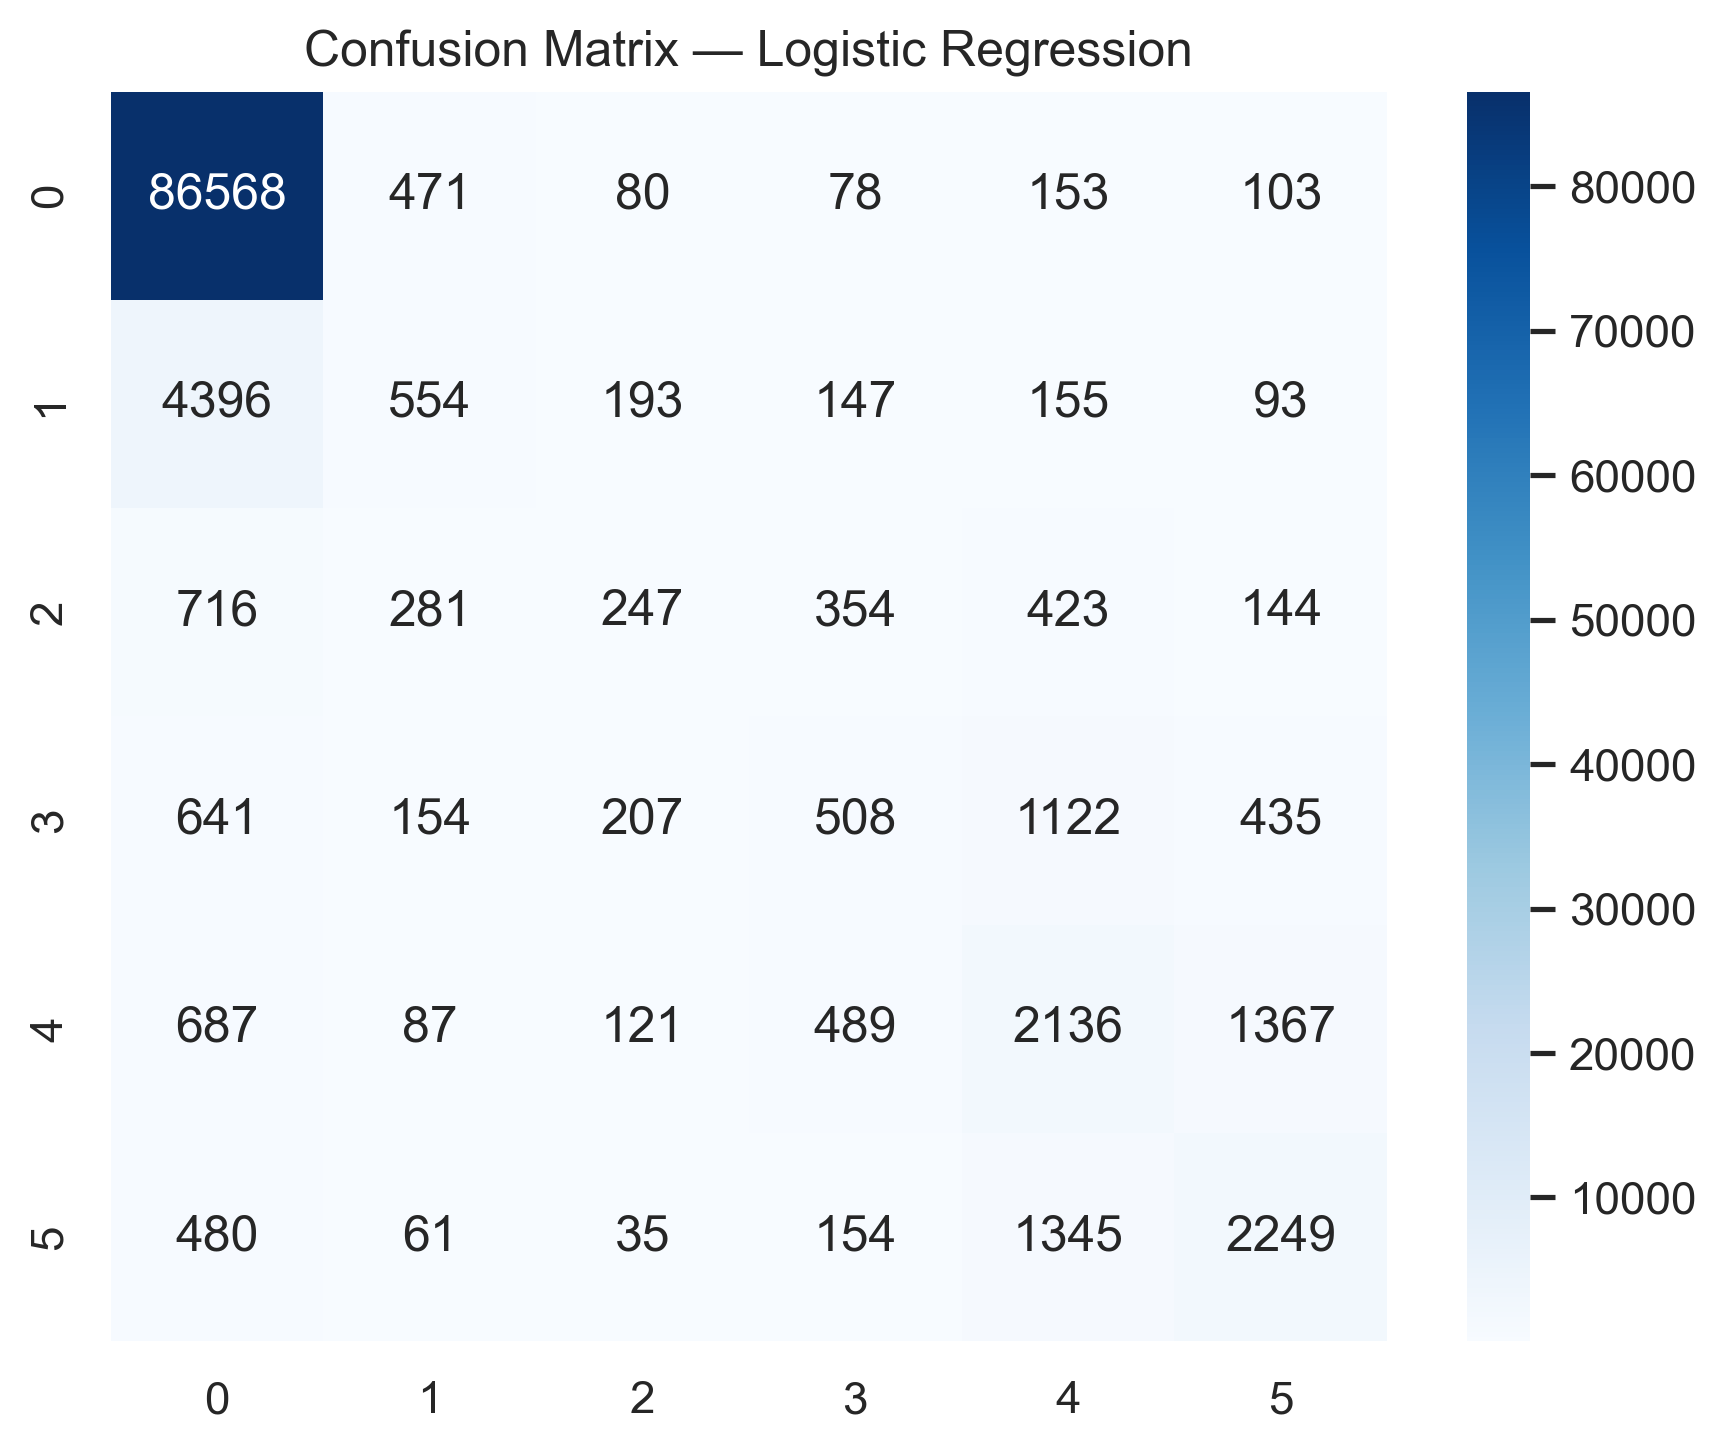

In [17]:
# Logistic Regression Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cm_logreg_text.png")
plt.show()

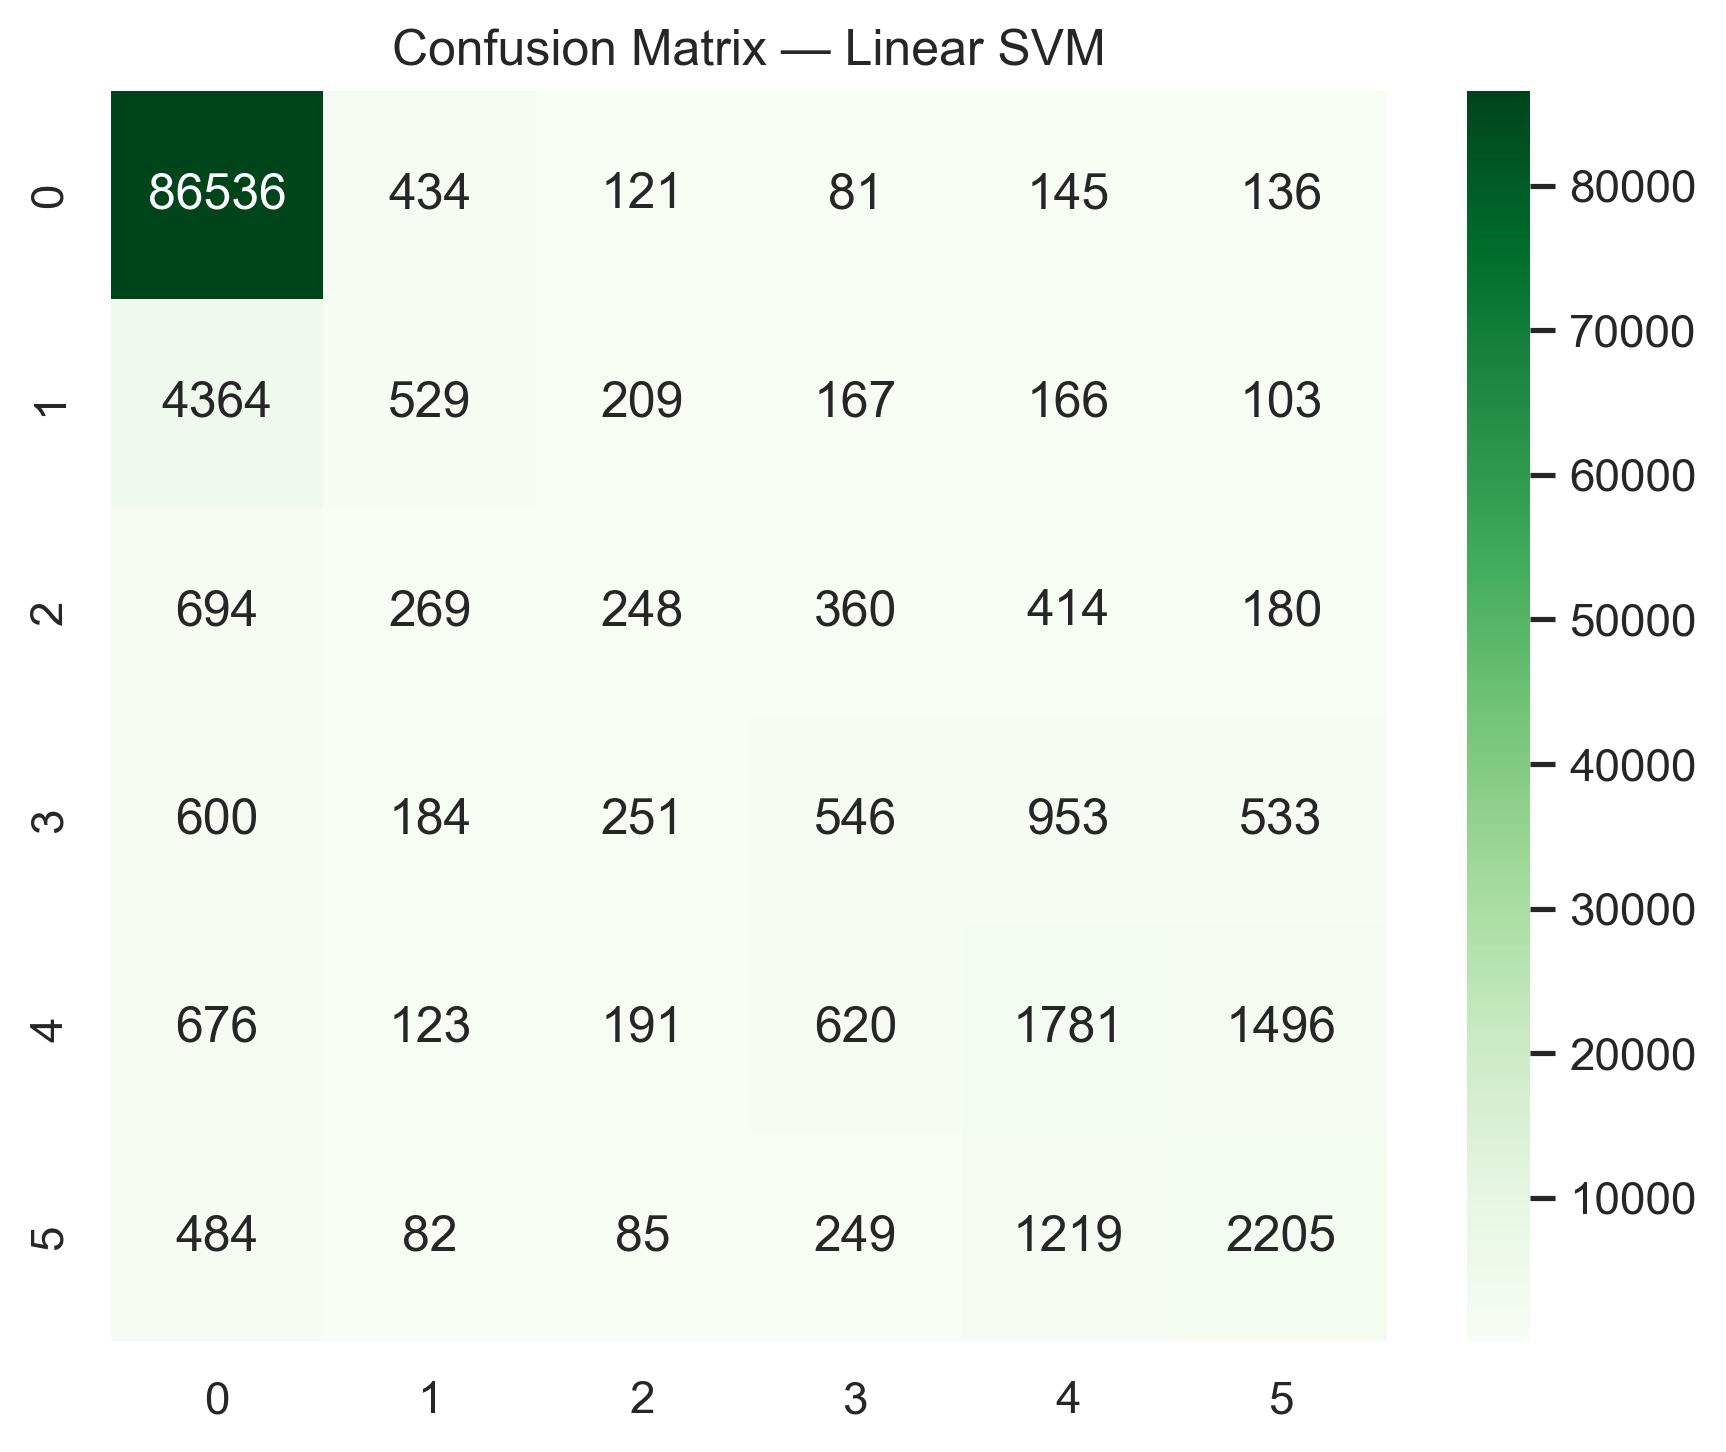

In [18]:
# SVM Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, cmap="Greens", fmt="d")
plt.title("Confusion Matrix — Linear SVM")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cm_svm_text.png")
plt.show()

## SECTION 12 — Global Feature Importance (TF-IDF Weights + Permutation Importance)


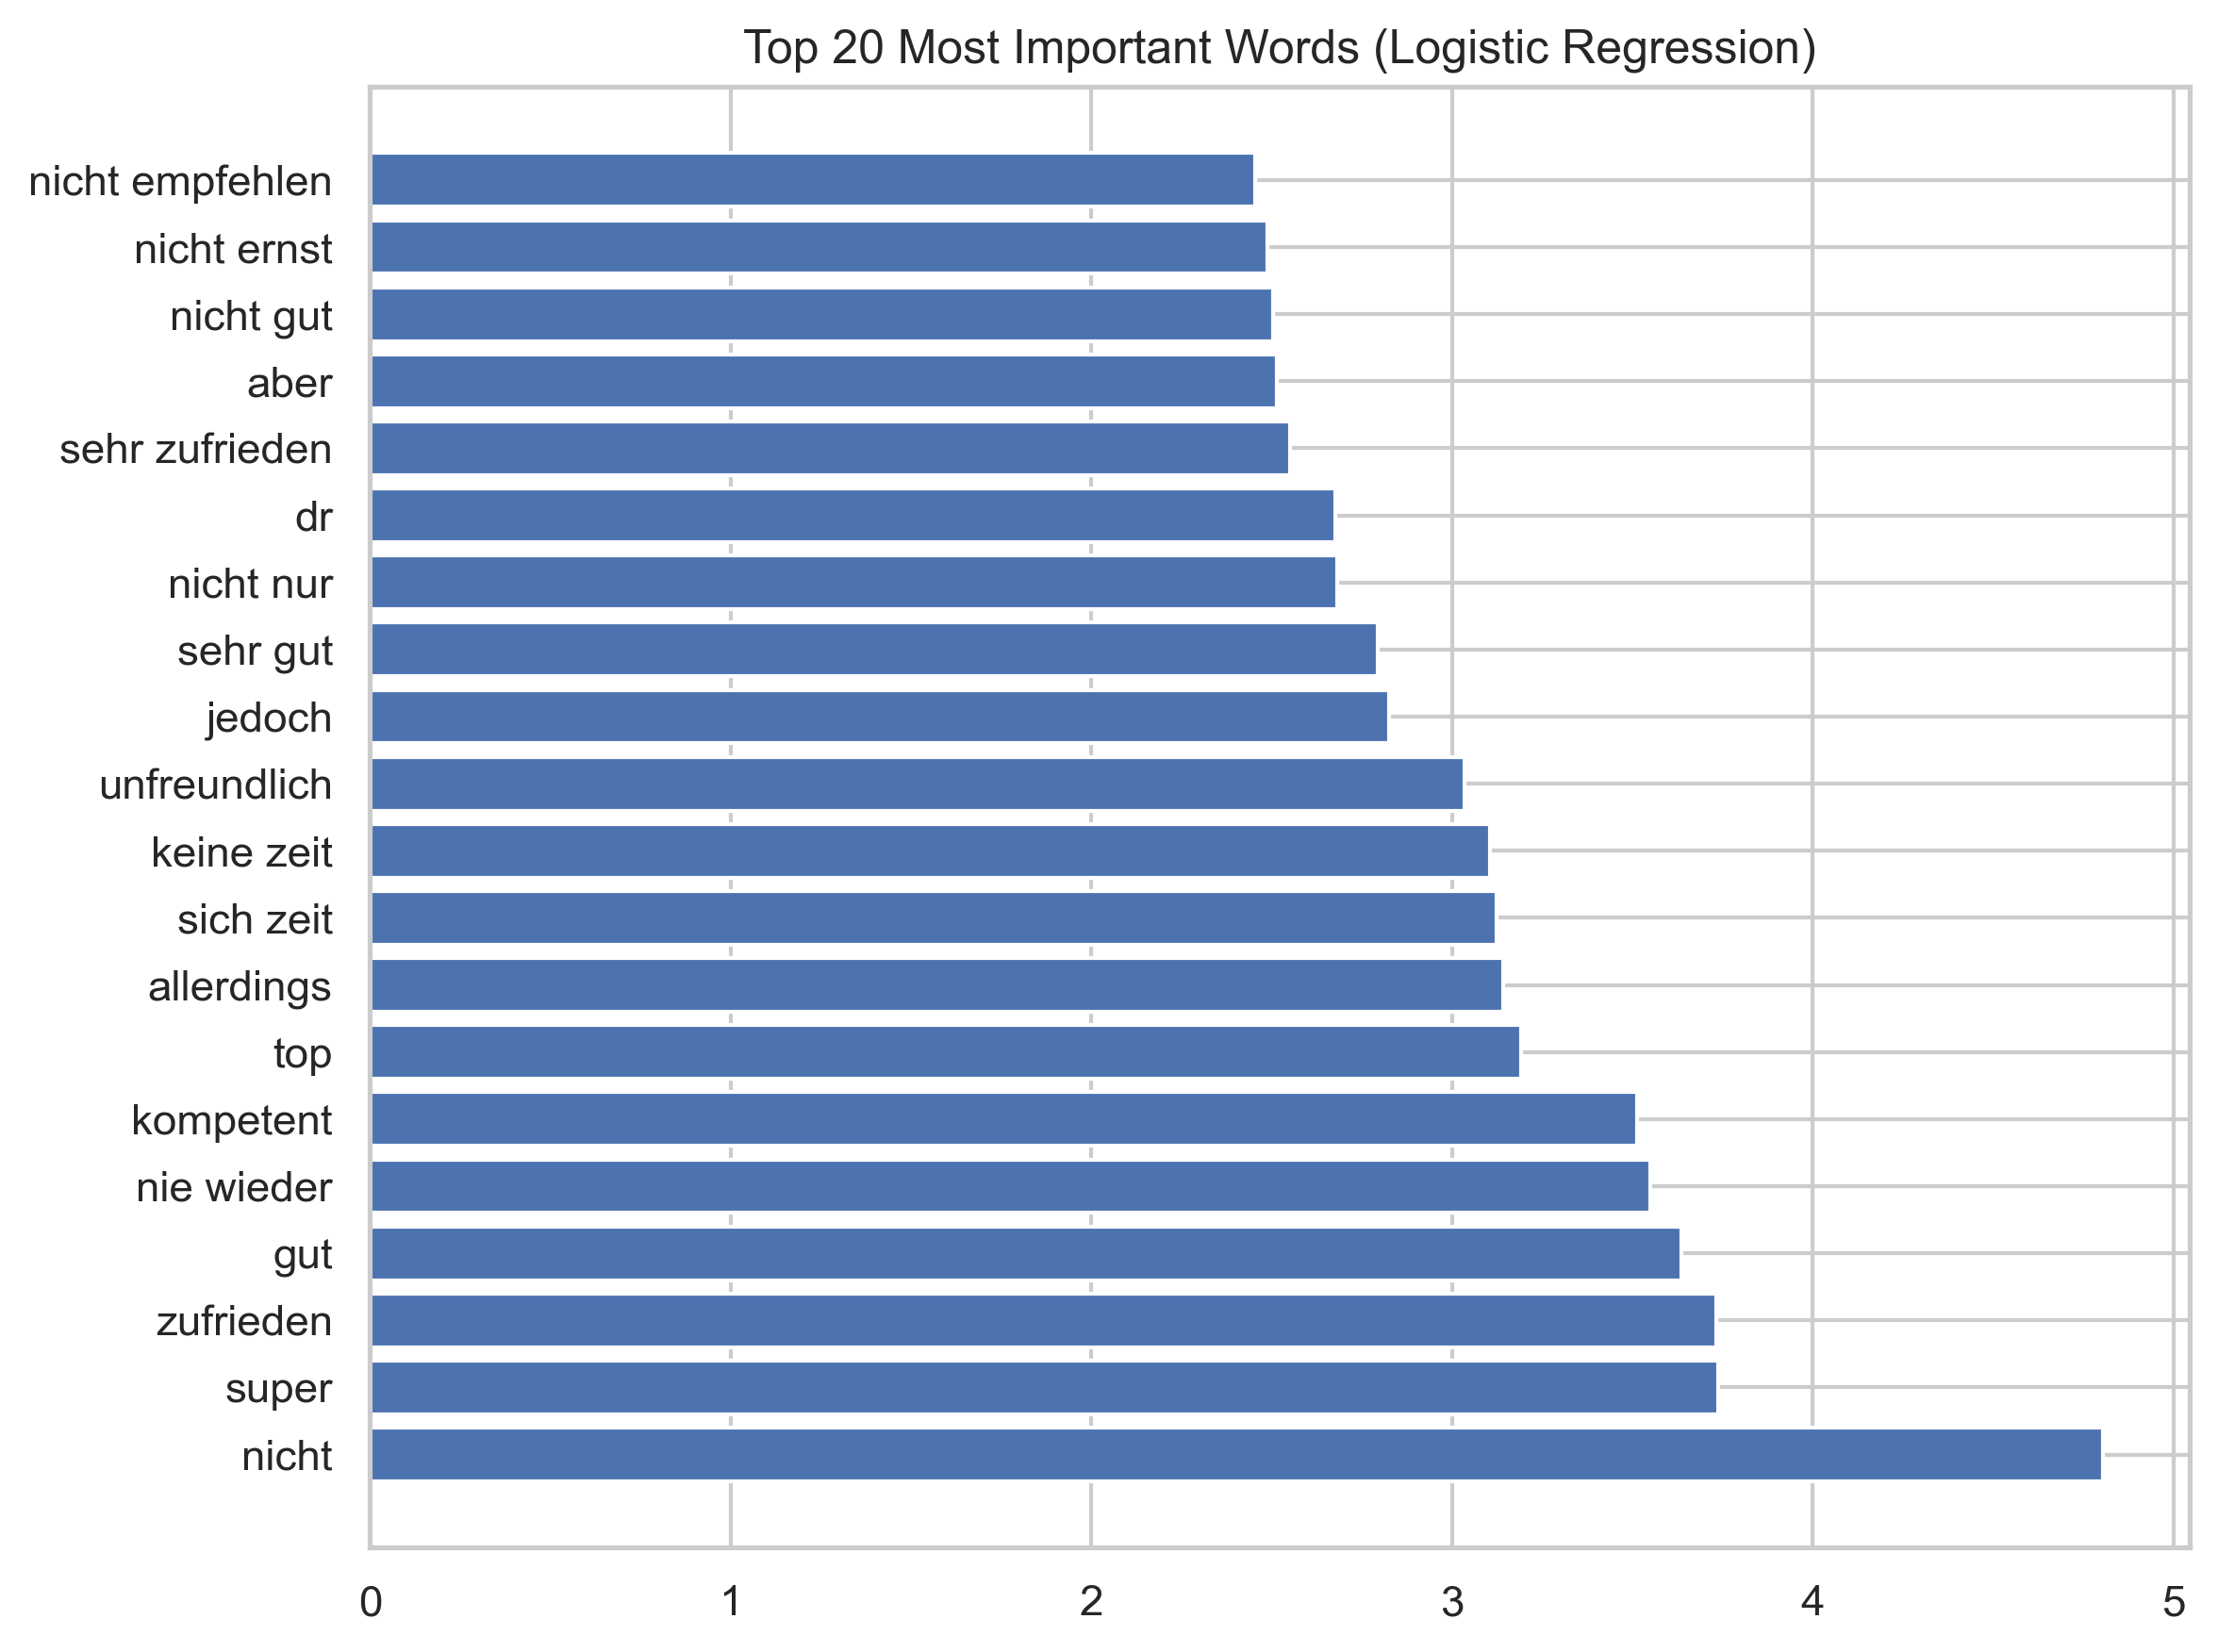

In [16]:
feature_names = tfidf.get_feature_names_out()
coeffs = lr_model.coef_

# For multiclass, average absolute weights
importance = np.mean(np.abs(coeffs), axis=0)

top_idx = np.argsort(importance)[-20:][::-1]

plt.figure(figsize=(8,6))
plt.barh(np.array(feature_names)[top_idx], importance[top_idx], color=DEFAULT_PALETTE[0])
plt.title("Top 20 Most Important Words (Logistic Regression)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/top_words_logreg.png")
plt.show()

## SECTION 13 — Word Importance via Logistic Regression Coefficients

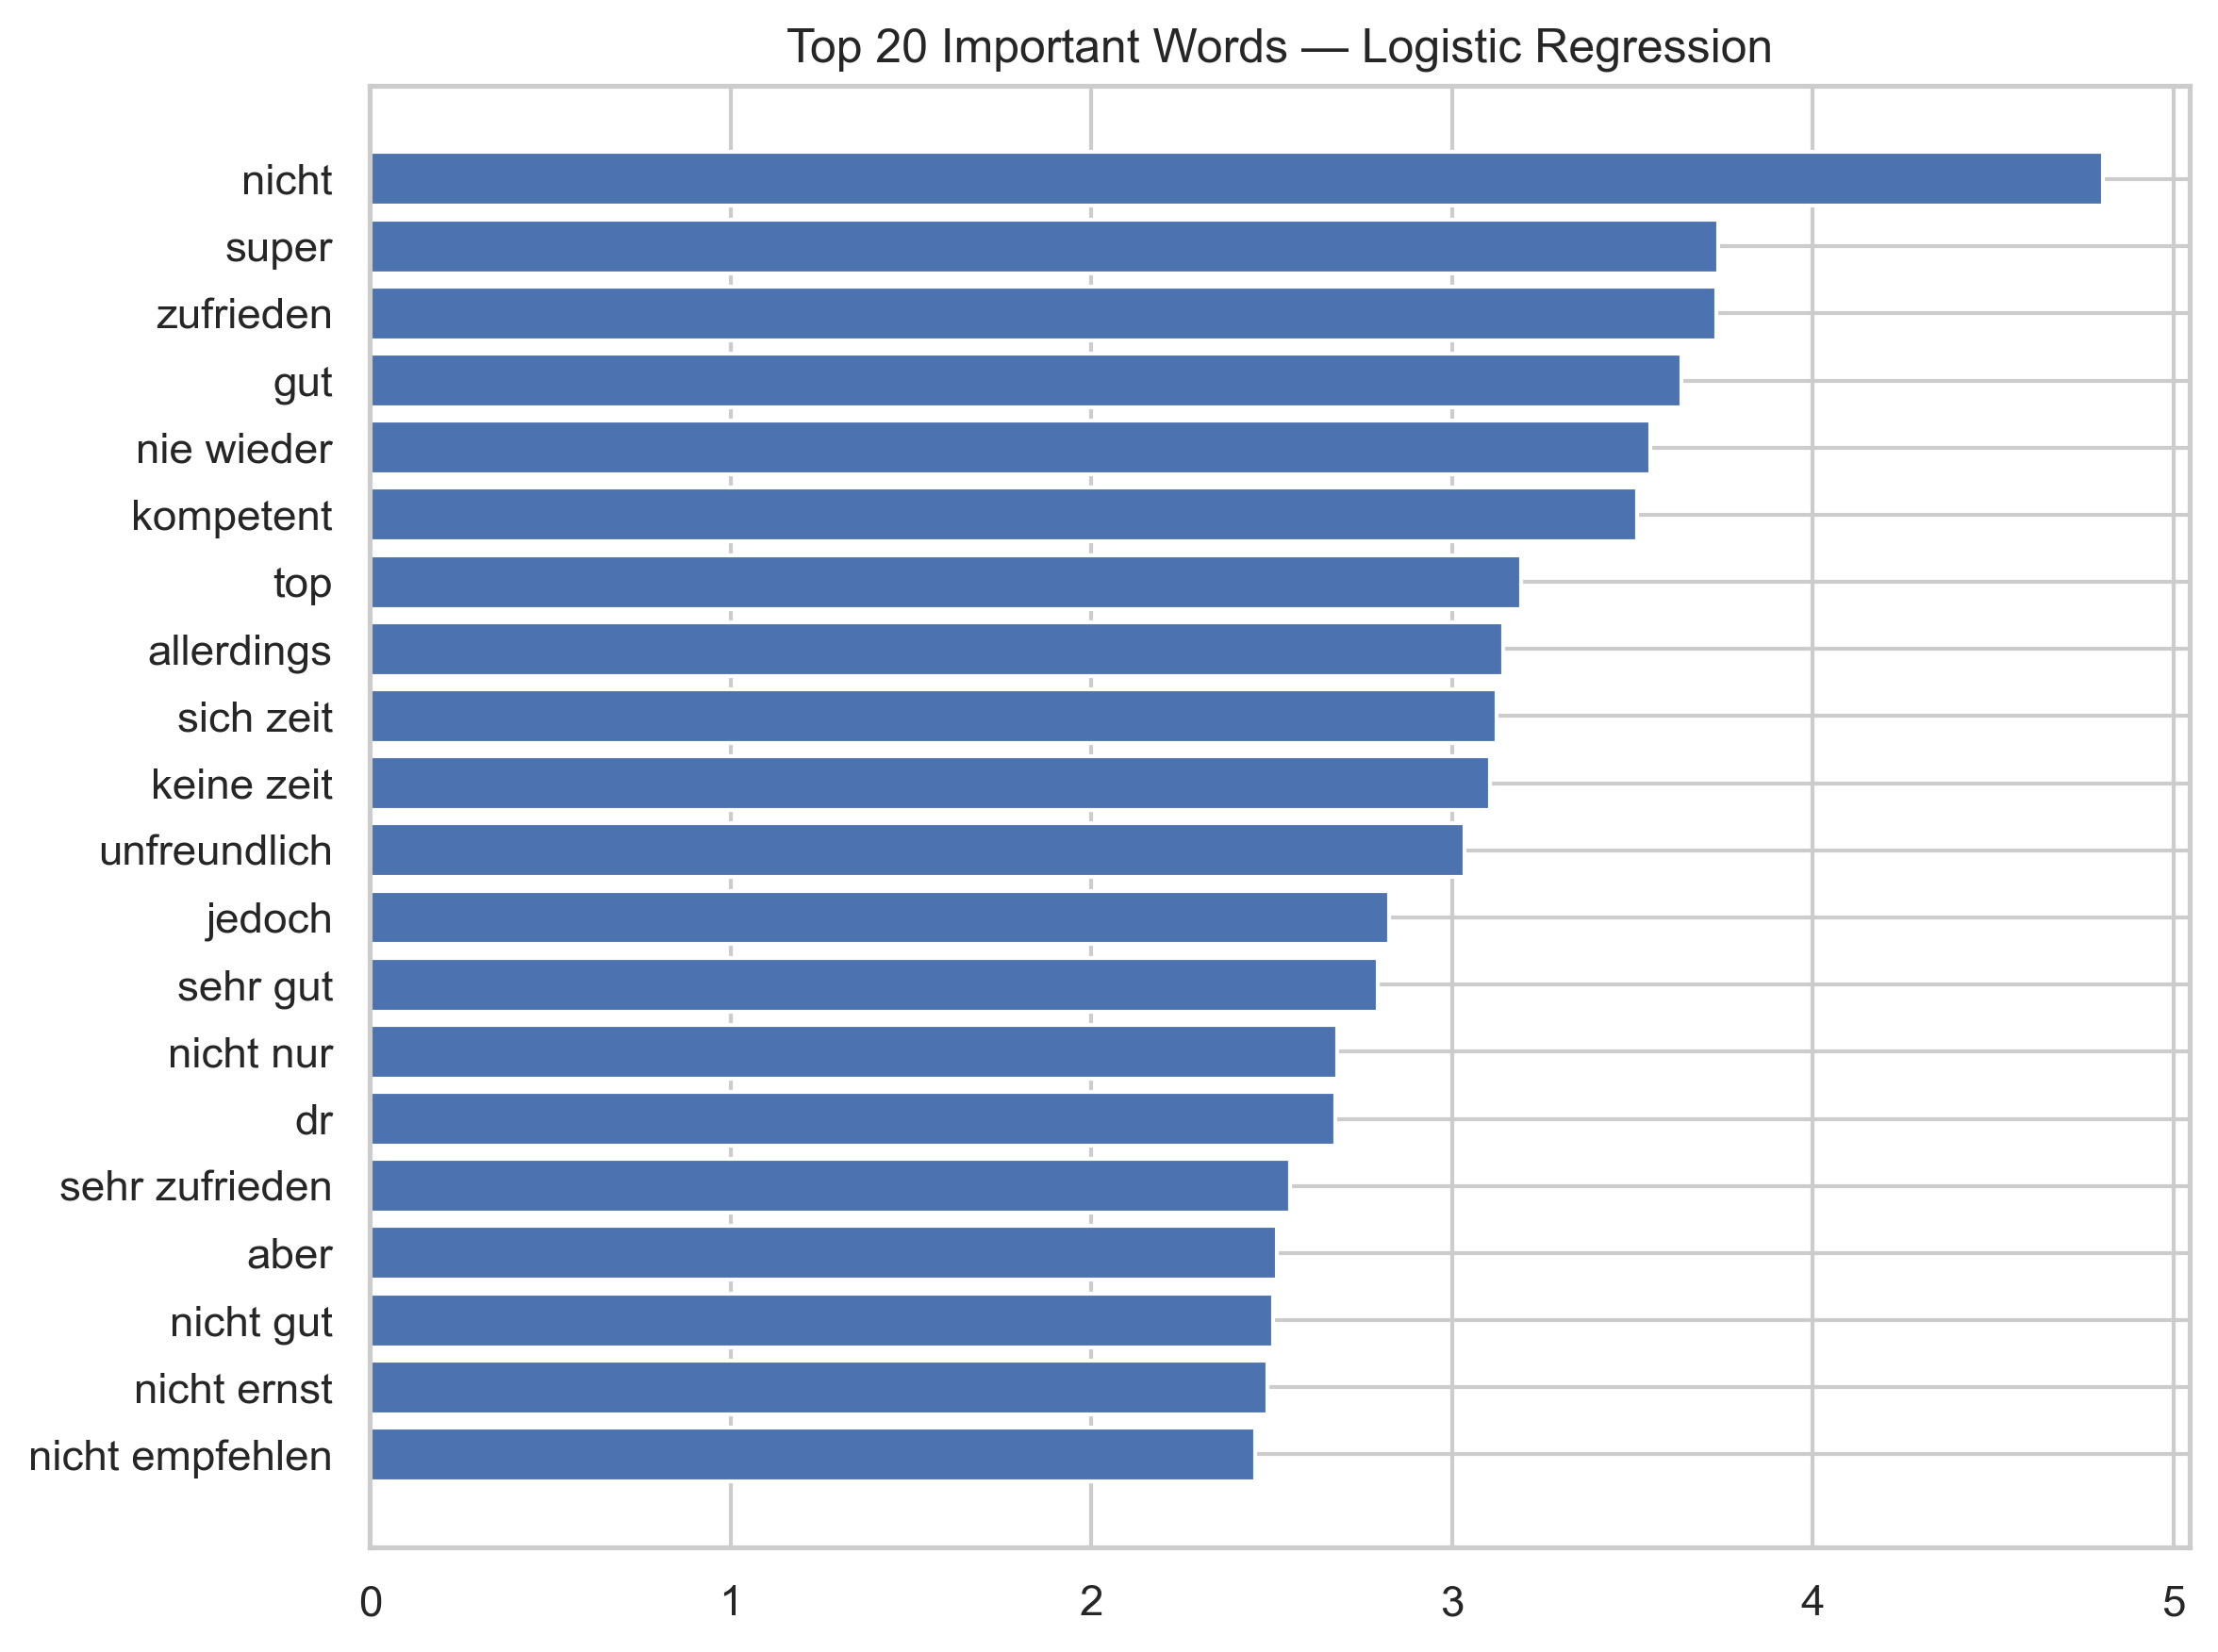

In [20]:
feature_names = tfidf.get_feature_names_out()

avg_weights = np.mean(np.abs(lr_model.coef_), axis=0)

topN = 20
top_idx = np.argsort(avg_weights)[-topN:]

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_idx], avg_weights[top_idx], color=DEFAULT_PALETTE[0])
plt.title("Top 20 Important Words — Logistic Regression")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/lr_top_words.png")
plt.show()

## SECTION 14 — Class-Specific Word Importance (SVM)

In [22]:
feature_names = tfidf.get_feature_names_out()

classes = svm_model.classes_  # actual class labels
coeff_matrix = svm_model.coef_  # shape: (n_classes, n_features)

print("Classes in model:", classes)

# For each class, extract top positive and negative features
for idx, class_label in enumerate(classes):
    coef = coeff_matrix[idx]

    # Top positive words
    top_pos_idx = np.argsort(coef)[-10:]
    top_pos_words = [feature_names[i] for i in top_pos_idx]

    # Top negative words
    top_neg_idx = np.argsort(coef)[:10]
    top_neg_words = [feature_names[i] for i in top_neg_idx]

    print(f"\n===== Class {class_label} =====")
    print("Top positive words:", top_pos_words)
    print("Top negative words:", top_neg_words)

Classes in model: [1. 2. 3. 4. 5. 6.]

===== Class 1.0 =====
Top positive words: ['top', 'hervorragenden', 'hervorragende', 'nicht schlimm', 'dankbar', 'entspannt', 'keine bessere', 'keine schmerzen', 'nicht nur', 'nicht enttäuscht']
Top negative words: ['nicht weiterempfehlen', 'nie wieder', 'abraten', 'nicht ernst', 'kaum zeit', 'unzureichend', 'keine empfehlung', 'respektlos', 'meiden', 'warnen']

===== Class 2.0 =====
Top positive words: ['schroff', 'überlege', 'absolut perfekt', 'ein kleines', 'dennoch ist', 'eigentlich sehr', 'br dennoch', 'pflegen', 'nicht anschließen', 'allerdings']
Top negative words: ['die mitarbeiterin', 'kommt der', 'ist soweit', 'den worten', 'nicht empfehlenswert', 'geht aber', 'nichtmal', 'der dann', 'erwischt', 'hier her']

===== Class 3.0 =====
Top positive words: ['zunehmend', 'geärgert', 'untersuchungen gemacht', 'ich relativ', 'nett aber', 'ist soweit', 'ist sicher', 'dringende', 'allerdings', 'jedoch']
Top negative words: ['sehr zufrieden', 'aufger